### Importation : 

In [17]:
import pandas as pd
import warnings
import sklearn
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

### Read Data :

In [18]:
def read_data(path):
    Data = pd.read_csv(path)
    return Data

df = read_data("MyRealData.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Describe :

In [19]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Info :

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Missing Values :

In [21]:
def fill_missing_values(data):
    missing_data = data.isnull().sum()
    Columns_missing = missing_data[missing_data > 0].index
    if len(Columns_missing) == 0:
        print("No missing values found.")
        return data
    else:
        for column in Columns_missing:
            if data[column].dtype in ['float64', 'int64']:
                mean_value = data[column].mean()
                data[column].fillna(mean_value, inplace=True)
            else:
                mode_value = data[column].mode()[0]
                data[column].fillna(mode_value, inplace=True)
        return data

df = fill_missing_values(df)
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Duplicated Rows :

In [24]:
def Duplicated_Check(Data):
    Duplicate_sum = Data.duplicated().sum()
    if Duplicate_sum == 0:
        print('You dont have any duplicated rows !!')
    else : 
        Data = Data.drop_duplicates()
        return Data
        
Duplicated_Check(df)

You dont have any duplicated rows !!


### remove the Id's Columns :

In [25]:
def remove_id(Data):
    Numeric_Data = Data.select_dtypes(include= ['float64', 'int64'])
    for column in Numeric_Data.columns :
        if Numeric_Data[column].unique().sum() == Numeric_Data[column].sum():
            Data = Data.drop(column, axis=1)
    return Data

remove_id(df)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Distribution de la variable cible :

In [26]:
def auto_normalize(Data):
    Numeric_Data = Data.select_dtypes(include= ['float64', 'int64'])
    for column in Numeric_Data.columns :
        if Numeric_Data[column].unique().sum() != Numeric_Data[column].sum():
            if not (Numeric_Data[column].min() >=0 and Numeric_Data[column].min() <=1) :
                scaled = MinMaxScaler()
                Data[column] = scaled.fit_transform(Data[[column]])
    return Data

auto_normalize(df)

   


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,0.291667,1.0,0.241379
1,738,16.42,Clear,Medium,Evening,Bike,0.625000,2.0,0.524138
2,741,9.52,Foggy,Low,Night,Scooter,0.958333,1.0,0.351724
3,661,7.44,Rainy,Medium,Afternoon,Scooter,0.000000,1.0,0.200000
4,412,19.03,Clear,Low,Morning,Bike,0.458333,5.0,0.413793
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,0.333333,3.0,0.317241
996,271,16.28,Rainy,Low,Morning,Scooter,0.125000,9.0,0.434483
997,861,15.62,Snowy,High,Evening,Scooter,0.875000,2.0,0.503448
998,436,14.17,Clear,Low,Afternoon,Bike,0.125000,0.0,0.324138


### Heatmap de corrélation :

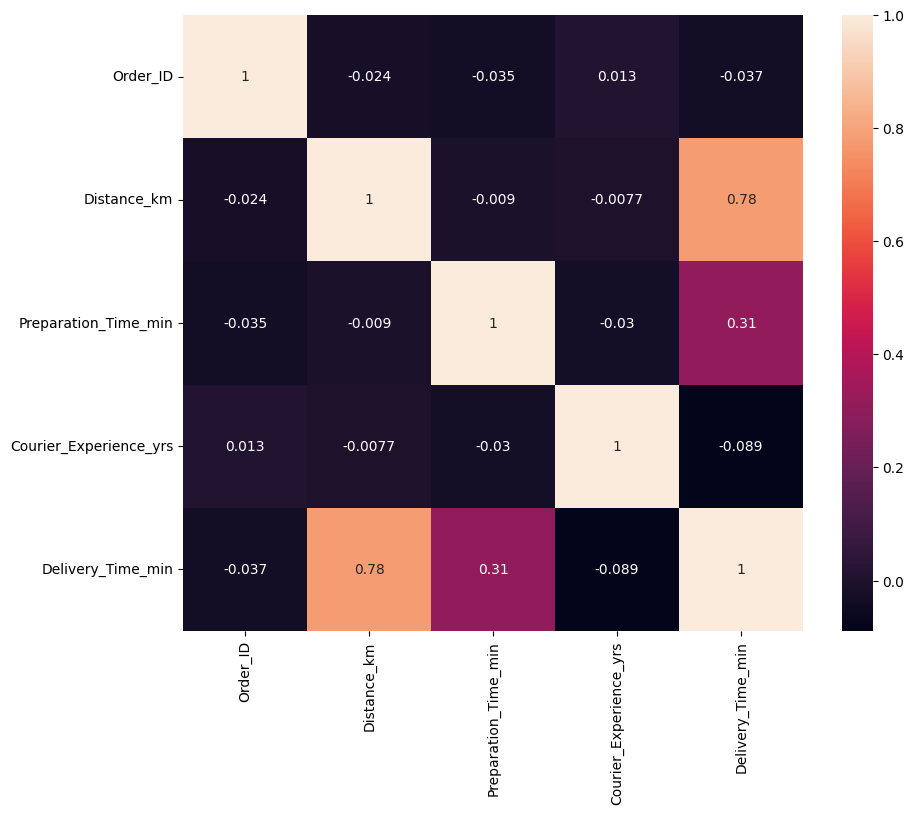

In [27]:
correlation_matrix = df.select_dtypes(include= ['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

### countplots for each featuers with target :

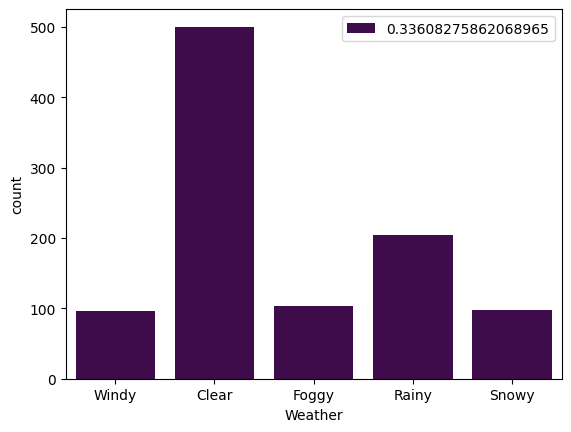

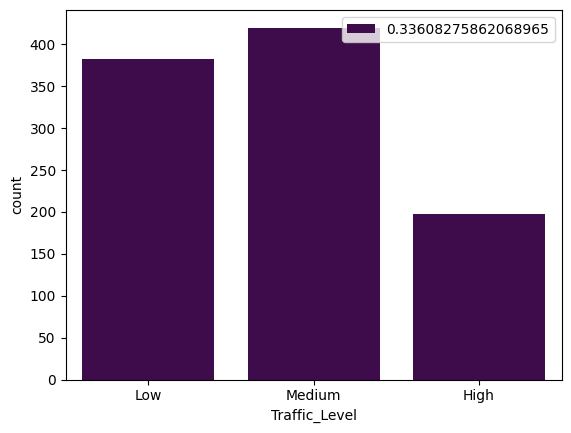

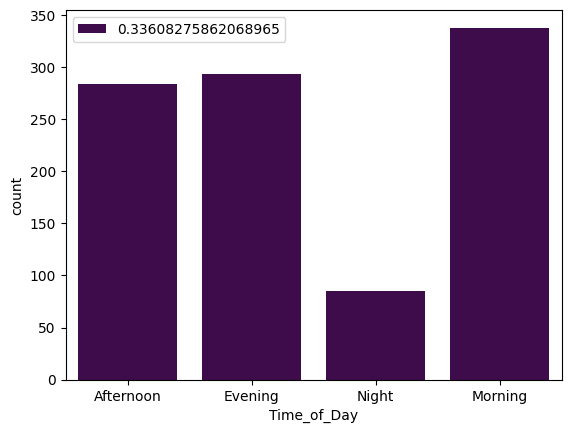

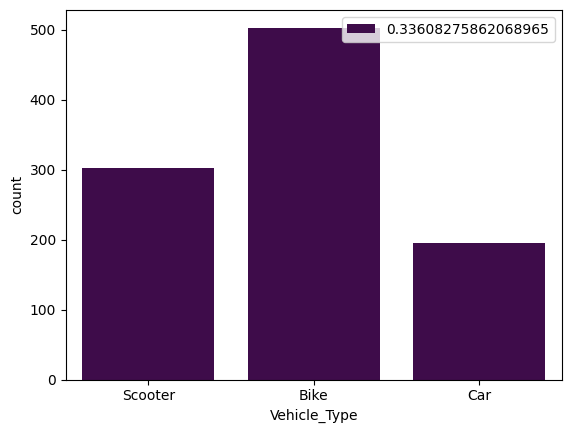

In [28]:
def Split_Object(Data):
    Object_Data = Data.select_dtypes(include=['object'])
    Target = Data['Delivery_Time_min']
    return Object_Data, Target

def Split_Num(Data):
    Object_Data = Data.select_dtypes(include=['int64','float64'])
    Target = Data['Delivery_Time_min']
    return Object_Data, Target

def count_plots(Features,Target): 
    for column in Features.columns:
        sns.countplot(x=column, hue=Target.mean(), data=df, palette='viridis')
        plt.show()

x,y = Split_Object(df) 

count_plots(x,y)

### Boxplots pour analyser la relation entre la cible et les variables catégorielles:

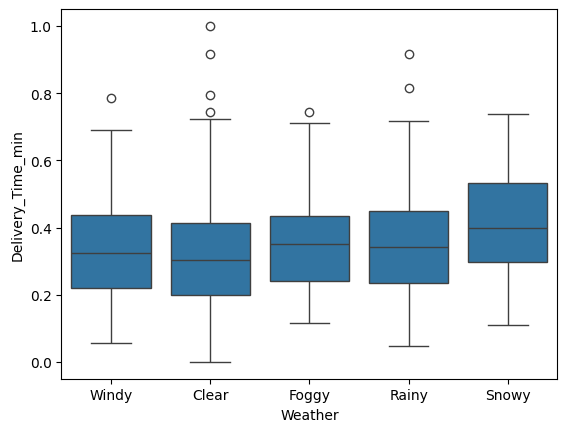

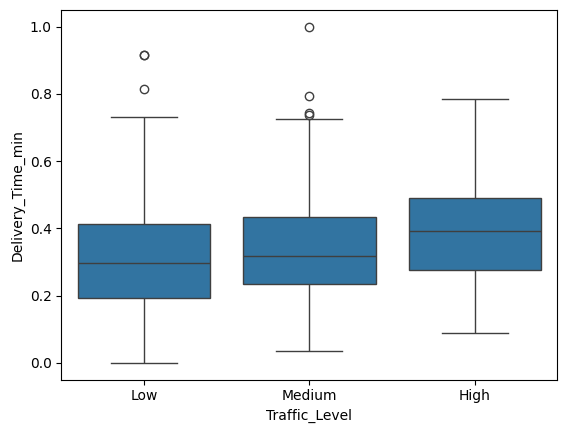

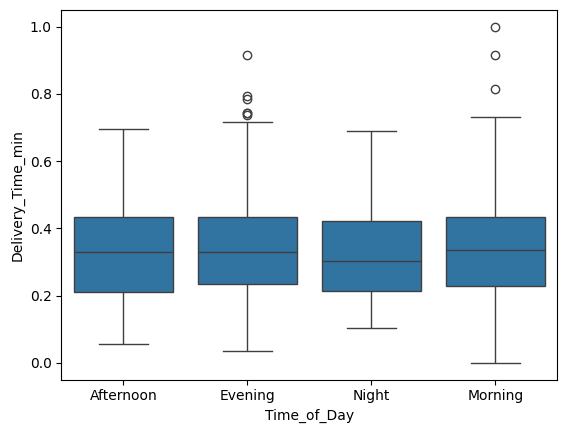

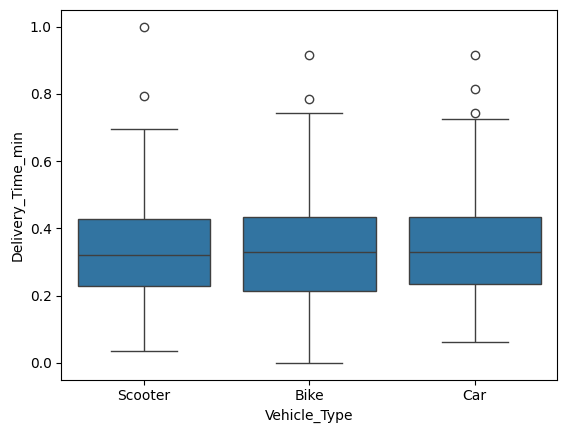

In [29]:
def count_plots(Features,Target): 
    for column in Features.columns:
        sns.boxplot(data=df, x=Features[column], y=Target)
        plt.show()

x,y = Split_Object(df)

count_plots(x,y)

### Encoder Data : 

In [30]:
def encode_Data(Data):
    Object_Data = Data.select_dtypes(include=['object'])
    encoder = LabelEncoder()
    for column in Object_Data.columns:
        Data[column] = encoder.fit_transform(Data[column])
    return Data

df = encode_Data(df)
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,0.291667,1.0,0.241379
1,738,16.42,0,2,1,0,0.625000,2.0,0.524138
2,741,9.52,1,1,3,2,0.958333,1.0,0.351724
3,661,7.44,2,2,0,2,0.000000,1.0,0.200000
4,412,19.03,0,1,2,0,0.458333,5.0,0.413793
...,...,...,...,...,...,...,...,...,...
995,107,8.50,0,0,1,1,0.333333,3.0,0.317241
996,271,16.28,2,1,2,2,0.125000,9.0,0.434483
997,861,15.62,3,0,1,2,0.875000,2.0,0.503448
998,436,14.17,0,1,0,0,0.125000,0.0,0.324138


### Split Data For Trainanig :

In [31]:
def Split_Data(Data):
    X = Data.drop(columns=['Delivery_Time_min', 'Order_ID', 'Vehicle_Type', 'Courier_Experience_yrs'], axis=1)
    y = Data['Delivery_Time_min']
    return X, y

def Split_train_test(Data):
    X, y = Split_Data(Data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = Split_train_test(df)


### GridSearshCV :

In [32]:
X, y = Split_Data(df)
model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

grid.fit(X, y)

print("Best Parameters:", grid.best_params_)
print("Best Score (R²):", grid.best_score_)


Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Score (R²): 0.7252132973549325
